In [1]:
import anndata as ad
import scanpy as sc
import hdf5plugin
import scipy
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
adamson_data = sc.read_h5ad(f"Data/AdamsonWeissman2016_GSM2406681_10X010/perturb_norm.h5ad")
norman_data = sc.read_h5ad(f"Data/NormanWeissman2019_filtered/perturb_norm.h5ad")

topo = "dorothea_tf2_abc"
replicate = "001"
path_to_data = f"Data/SimulResults_Racipe/{topo}/{replicate}/{topo}_steadystate_solutions_{replicate}"
grins_data = sc.read_h5ad(f"{path_to_data}.h5ad")

# Plot Counts:

## Norman:

In [17]:
norman_mean = np.asarray(norman_data.layers["log1p"].mean(axis=0)).squeeze()
n_squared = norman_data.layers["log1p"].multiply(norman_data.layers["log1p"])
norman_var = np.asarray(np.mean(n_squared,axis=0)).squeeze()-norman_mean*norman_mean

r_norman_mean = np.asarray(norman_data.X.mean(axis=0)).squeeze()
r_n_squared = norman_data.X.multiply(norman_data.X)
r_norman_var = np.asarray(np.mean(r_n_squared,axis=0)).squeeze()-r_norman_mean*r_norman_mean

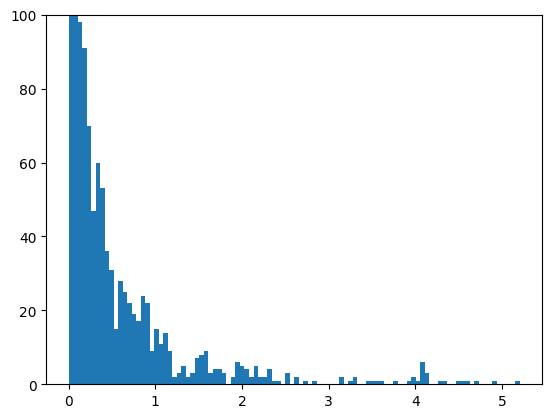

In [18]:
plt.hist(norman_mean,bins=100)
plt.ylim(0,100)
plt.show()

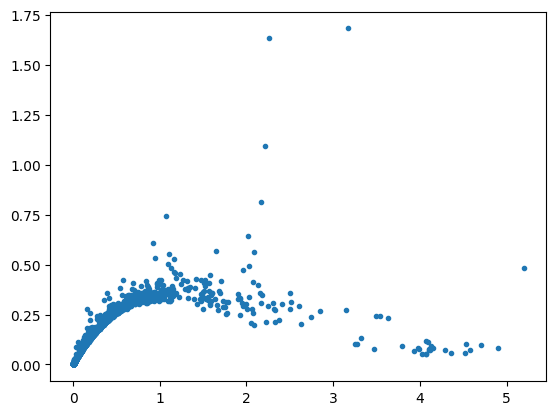

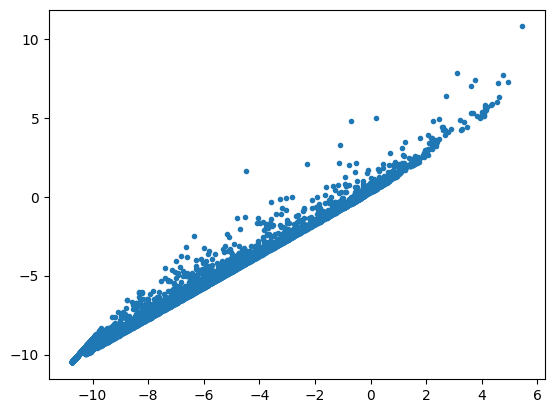

In [19]:
plt.plot(norman_mean,norman_var,".")
plt.show()
plt.plot(np.log(r_norman_mean),np.log(r_norman_var),".")
plt.show()

## GRiNS:

In [20]:
grins_mean = np.asarray(grins_data.layers["log1p"].mean(axis=0)).squeeze()
g_squared = grins_data.layers["log1p"].multiply(grins_data.layers["log1p"])
grins_var = np.asarray(np.mean(g_squared,axis=0)).squeeze()-grins_mean*grins_mean

r_grins_mean = np.asarray(grins_data.X.mean(axis=0)).squeeze()
r_g_squared = grins_data.X.multiply(grins_data.X)
r_grins_var = np.asarray(np.mean(r_g_squared,axis=0)).squeeze()-r_grins_mean*r_grins_mean

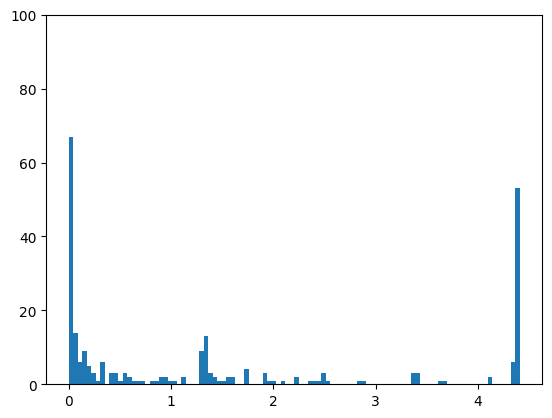

In [21]:
plt.hist(grins_mean,bins=100)
plt.ylim(0,100)
plt.show()

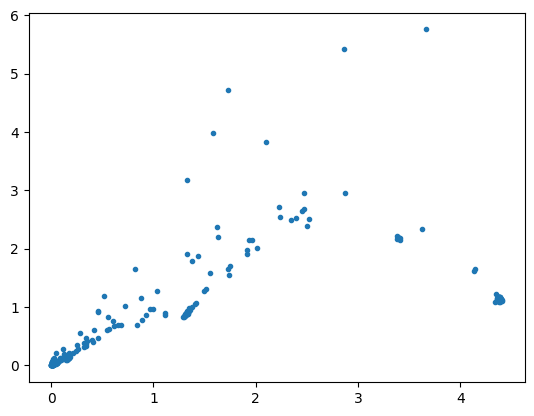

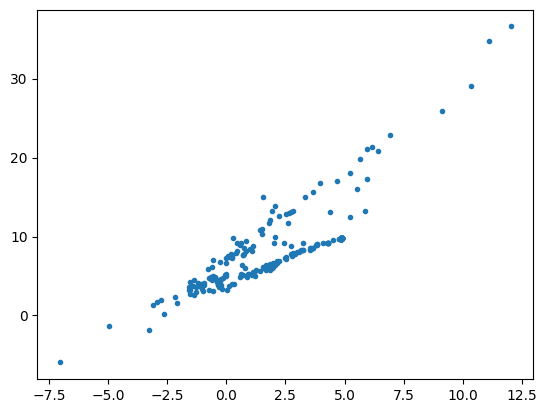

In [22]:
plt.plot(grins_mean,grins_var,".")
plt.show()
plt.plot(np.log(r_grins_mean),np.log(r_grins_var),".")
plt.show()

## Takeaway:
- Despite the smaller sample size, the data more or less looks the same for GRiNS as for Norman
- At the same time, the peak at the upper end of the GRiNS histogram is strange

# Find good metrics to predict `pct_dropout_by_counts`

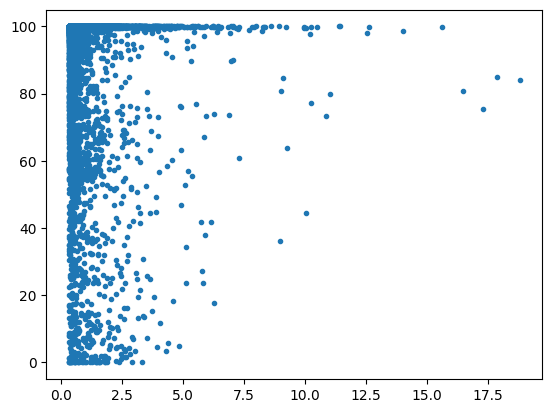

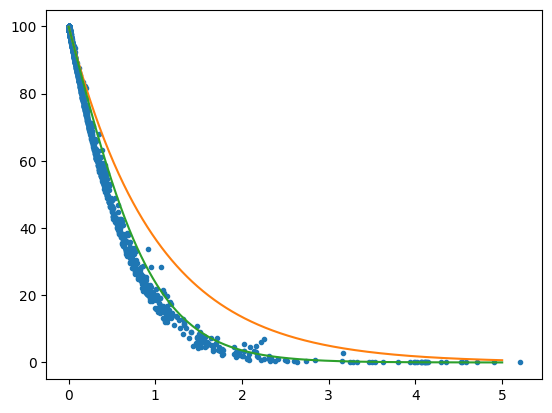

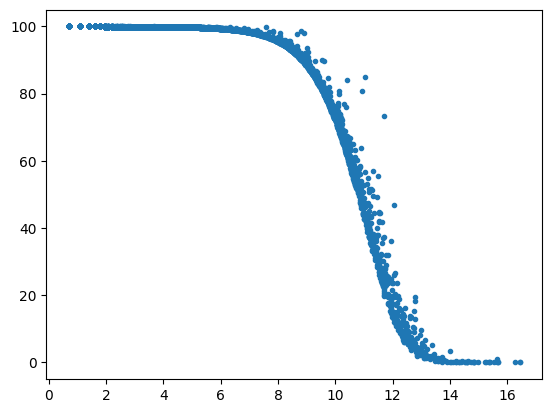

In [ ]:
plt.plot(adamson_data.var["dispersions_norm"],adamson_data.var["pct_dropout_by_counts"],".") # No correlation between dropout rate and dispersion
plt.show()
fig, ax = plt.subplots()
ax.plot(norman_mean,norman_data.var["pct_dropout_by_counts"],".") # dropout rate and mean counts related through gamma dist
x = np.linspace(0.001,5,1000)
k = 1
plt.plot(x,100*k*np.exp(-k*x))
plt.plot(x,100*2*1/(1+np.exp(-(-2)*x))) # Sigmoid works surprisingly well, but why? -> sigmoid is cdf of logistic dist
ax.plot()
plt.show()
plt.plot(adamson_data.var["log1p_total_counts"],adamson_data.var["pct_dropout_by_counts"],".") # dropout rate and total counts related through logit dist (or cumul gamma?)
plt.show()

In [ ]:
# Naive idea: find the percentage of non-zero cells
scipy.sparse.csr_matrix.getnnz(ctrl_norm_data.X)/(ctrl_norm_data.X.shape[0]*ctrl_norm_data.X.shape[1])

4400654

## Discarded: Subclass of stats.rv_continuous for gamma-normal

In [337]:
class gamma_normal_gen(stats.rv_continuous):
    "Gamma Distribution"
    def __init__(self):
        self.shapes="lamb, alpha, beta"
        self.a = 0.
    def _argcheck(self,x,lamb,alpha,beta):
        return (0<=lamb<=1) & (0<alpha<=10) & (0<beta<=10)
    def _pdf(self,x,lamb,alpha,beta):#,mu,sigma):
        return lamb*stats.gamma.pdf(x,alpha,scale=beta)#+(1-lamb)*(np.exp(-(x-mu)**2/(2*sigma**2))/np.sqrt(2.0*np.pi*sigma**2))#
    #def _shape_info(self):
    #    return [_ShapeInfo("lamb, alpha, beta", False, [(0,1),(0,10),(0,10)])]
    

In [338]:
gn = gamma_normal_gen()#a=0.,shapes="lamb,alpha,beta")

In [332]:
shapes = (0.5,1,0.5,0,1)
shapes = (0.5,1.0,0.5,1.0,1.0)

In [339]:
gn.pdf(2,0.5,1.0,0.5)

AttributeError: 'gamma_normal_gen' object has no attribute '_parse_args'

In [ ]:
data = stats.gamma.rvs(1.0,1.0,size=10)

In [ ]:
stats.fit(gn,data,[(0,1),(0,3),(0,3)])

ValueError: Distribution `Distribution` is not yet supported by `scipy.stats.fit` because shape information has not been defined.

In [ ]:
stats.norm.rvs(1,1,size=10)

array([-0.07085624,  1.21153099,  1.46395751,  2.87962498,  0.57603295,
        1.94808404,  0.68883281,  2.03233699,  1.1937067 ,  1.36900526])

In [299]:
gn.rvs(*shapes,size=10,random_state=np.random.default_rng())

/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2046: RuntimeWarning: overflow encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


ValueError: The function value at x=nan is NaN; solver cannot continue.

In [ ]:
stats.norm.pdf(1,0,2)

np.float64(0.17603266338214973)

## Maybe viable: Use optimize.minimize

In [ ]:
y_axis = adamson_data.var["log1p_mean_counts"].to_numpy()#np.linspace(0, 20, num=5_000)
pdf_y = adamson_data.var["pct_dropout_by_counts"].to_numpy()#two_gamma(y_axis, W, ALPHA1, SCALE1, ALPHA2, SCALE2) #w*g1 + (1-w)*g2

#Sample data for testing
Y = np.vstack([y_axis,pdf_y]).T[:500]

In [143]:
dist = stats.expon
res = stats.fit(dist,y_axis)

FitParams(loc=np.float64(0.0), scale=np.float64(1.0))


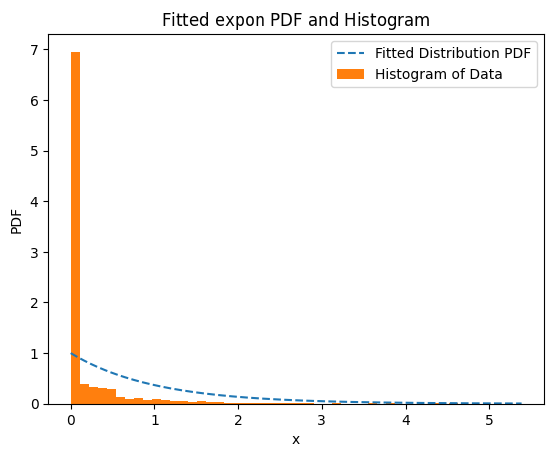

In [144]:
res.plot()
print(res.params)

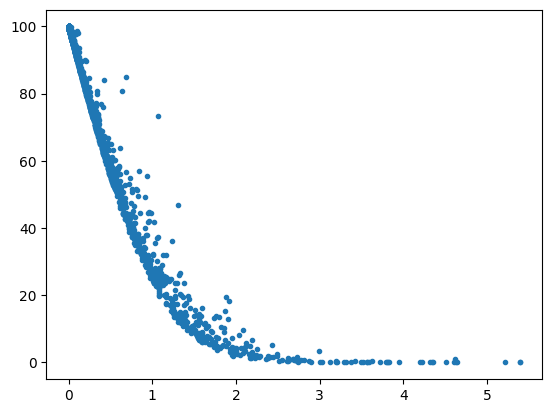

In [14]:
plt.plot(y_axis,pdf_y,".")

In [34]:
def gamma_normal(x, lamb, alpha, beta, mu, sigma):
    #Construct the current estimated PDF
    gamma_pdf = 100*stats.gamma.pdf(x, alpha, scale=beta)
    norm_pdf = 100*stats.norm.pdf(x,mu,scale=sigma)
    #norm_pdf = stats.norm.pdf(x,mu,sigma)
    y_pdf_estimate = lamb * gamma_pdf + (1 - lamb) * norm_pdf

    return y_pdf_estimate


In [ ]:
def gn_mle(params):
    y_pdf_estimate = gamma_normal(Y,*params)

    avg_neg_ll = -np.log(y_pdf_estimate+1e-8).mean()
    return avg_neg_ll

In [ ]:
initial_guess = [1]*5
bounds = [(0,1)]+[(0,None)]*4
results = scipy.optimize.minimize(gn_mle,x0=initial_guess,bounds=bounds)
estimated_params = (w, alpha1, scale1, alpha2, scale2) = results['x']

In [ ]:
y_pdf_fit = gamma_normal(adamson_data.var["log1p_mean_counts"][:500], *estimated_params)

In [153]:
estimated_params

array([0.5])

(0.0, 300.0)

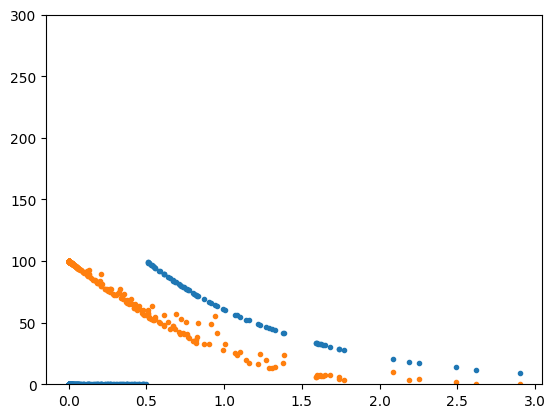

In [ ]:
fig, ax = plt.subplots()
ax.plot(y_axis[:500],y_pdf_fit,".")
ax.plot(y_axis[:500],pdf_y[:500],".")
ax.set_ylim(0,1)
#ax.plot(adamson_data.var["log1p_mean_counts"],adamson_data.var["pct_dropout_by_counts"],".")